# BTS RAG Agent

In [ ]:
"""
agent structure

                            unknown intent or complicated question
                        --------------------------------------------> plan agent(brain storm agent) -----> fetch useful knowledge graph ------> summarize the graph based on manual
                        |
                        |            known intent
    question -----> intent router ------------------> rag agent(normal agent) ----------> graph agent: get adj node to show the little part of the knowledge graph

"""

## Requirements

In [ ]:
!pip install langchain langchain_community networkx transformers langchain-huggingface sentence_transformers

## Global Params

In [ ]:
docs = ""

## Create and load the graph

In [ ]:
import networkx as nx
from collections import deque
import pickle
from typing import Dict, List, Tuple, Any

In [ ]:
# ==================== 保存图 ====================
def save_graph(graph, filename="my_graph.pkl"):
    """
    保存图到文件（最简单的方法）

    Args:
        graph: Networkx图对象
        filename: 保存的文件名
    """
    with open(filename, "wb") as f:
        pickle.dump(graph, f)
    print(f"✅ 图已保存到: {filename}")


# ==================== 加载图 ====================
def load_graph(filename="my_graph.pkl"):
    """
    从文件加载图（最简单的方法）

    Args:
        filename: 要加载的文件名

    Returns:
        加载的图对象
    """
    with open(filename, "rb") as f:
        graph = pickle.load(f)
    print(f"✅ 已从 {filename} 加载图")
    print(f"   节点数: {graph.number_of_nodes()}")
    print(f"   边数: {graph.number_of_edges()}")
    return graph

In [ ]:
def query_node_relationships(DG: nx.DiGraph, node_name: str) -> Dict[str, List[str]]:
    """
    查询节点的包含关系（contains_arr）和属于关系（related_arr）

    Args:
        DG: Networkx有向图
        node_name: 要查询的节点名称

    Returns:
        包含 contains_arr 和 related_arr 的字典
    """
    if node_name not in DG:
        return {
            "node_name": node_name,
            "contains_arr": [],
            "related_arr": [],
            "error": f"节点 '{node_name}' 不存在",
        }

    contains_arr = []
    related_arr = []

    # 查询所有出边（节点指向其他节点）
    for _, target, data in DG.out_edges(node_name, data=True):
        if data.get("type") == "包含":
            contains_arr.append(target)

    # 查询所有入边（其他节点指向该节点）
    for source, _, data in DG.in_edges(node_name, data=True):
        if data.get("type") == "包含":
            related_arr.append(source)

    return {
        "node_name": node_name,
        "contains_arr": sorted(contains_arr),  # 排序使输出更整齐
        "related_arr": sorted(related_arr),
    }

def query_all_nodes(DG: nx.DiGraph):
    return DG.nodes()

def query_all_nodes_by_label(DG: nx.DiGraph, label: str):
    return_nodes = []
    for node_id, attrs in DG.nodes(data=True):
        # print(f"节点 {node_id}: {attrs['labels']}")
        if len(attrs["labels"]) != 1:
            continue
        if attrs["labels"][0] == label:
            return_nodes.append(node_id)

def extract_upward_subgraph(G, start_nodes, relation_type="属于"):
    """
    从起始节点向上抽取子图（沿着关系类型的反方向）
    
    Args:
        G: 原始有向图
        start_nodes: 起始节点列表
        relation_type: 关系类型
    
    Returns:
        向上抽取的子图
    """
    # 收集所有需要包含的节点
    nodes_to_include = set(start_nodes)
    
    # 使用队列进行 BFS
    queue = deque(start_nodes)
    visited = set(start_nodes)
    
    while queue:
        current = queue.popleft()
        # print(current)
        
        # 查找所有指向当前节点的边（即出边）
        for successor in G.successors(current):
            # print(successor)
            # 检查这条边的类型是否为指定的关系类型
            edge_data = G.get_edge_data(current, successor)
            if edge_data and edge_data.get('type') == relation_type:
                if successor not in visited:
                    visited.add(successor)
                    nodes_to_include.add(successor)
                    queue.append(successor)
    
    # 返回子图
    # 打印结果
    subgraph = G.subgraph(nodes_to_include).copy()
    content = ""
    content += "子图中的节点:\n"
    for node in subgraph.nodes():
        node_type = subgraph.nodes[node].get('type', '未知')
        content += f"  - {node} ({node_type})\n"

    content += "子图中的边:\n"
    for u, v, data in subgraph.edges(data=True):
        content += f"  {u} -> {v} (type: {data.get('type')})\n"
    return content

### Create knowledge graph manually

In [ ]:
def init_graph():
    DG = nx.DiGraph()
    DG.add_node("IPS系统", type="系统")
    DG.add_node("生管控制界面", type="界面")
    DG.add_node("系统设置界面", type="界面")
    DG.add_node("QDM基础表界面", type="界面")
    DG.add_node("基础信息界面", type="界面")
    DG.add_node("报表管理界面", type="界面")
    DG.add_node("预警管理界面", type="界面")
    DG.add_node("工单管理界面", type="界面")
    DG.add_node("图形化控制界面", type="界面")
    DG.add_node("生管总控界面", type="界面")
    DG.add_node("SF1生管界面", type="界面")
    DG.add_node("SF2生管界面", type="界面")
    DG.add_node("追加订单操作", type="操作")
    DG.add_node("停换操作", type="操作")
    DG.add_node("刷新操作", type="操作")
    DG.add_node("强换操作", type="操作")
    DG.add_node("重传操作", type="操作")

    # add edges
    DG.add_edge("IPS系统", "生管控制界面", type="包含")
    DG.add_edge("生管控制界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "系统设置界面", type="包含")
    DG.add_edge("系统设置界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "QDM基础表界面", type="包含")
    DG.add_edge("QDM基础表界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "基础信息界面", type="包含")
    DG.add_edge("基础信息界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "报表管理界面", type="包含")
    DG.add_edge("报表管理界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "预警管理界面", type="包含")
    DG.add_edge("预警管理界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "工单管理界面", type="包含")
    DG.add_edge("工单管理界面", "IPS系统", type="属于")
    DG.add_edge("IPS系统", "图形化控制界面", type="包含")
    DG.add_edge("图形化控制界面", "IPS系统", type="属于")
    DG.add_edge("生管控制界面", "生管总控界面", type="包含")
    DG.add_edge("生管总控界面", "生管控制界面", type="属于")
    DG.add_edge("生管总控界面", "SF1生管界面", type="包含")
    DG.add_edge("SF1生管界面", "生管总控界面", type="属于")
    DG.add_edge("生管总控界面", "SF2生管界面", type="包含")
    DG.add_edge("SF2生管界面", "生管总控界面", type="属于")

    DG.add_edge("生管总控界面", "追加订单操作", type="包含")
    DG.add_edge("追加订单操作", "生管总控界面", type="属于")
    DG.add_edge("生管总控界面", "停换操作", type="包含")
    DG.add_edge("停换操作", "生管总控界面", type="属于")
    DG.add_edge("生管总控界面", "刷新操作", type="包含")
    DG.add_edge("刷新操作", "生管总控界面", type="属于")
    DG.add_edge("生管总控界面", "强换操作", type="包含")
    DG.add_edge("强换操作", "生管总控界面", type="属于")
    DG.add_edge("生管总控界面", "重传操作", type="包含")
    DG.add_edge("重传操作", "生管总控界面", type="属于")
    save_graph(DG, filename="/kaggle/working/bts_graph.pkl")

### Create knowledge graph by exported json file

In [ ]:
import json
def convert_to_networkx_digraph(json_path):
    """
    将给定的JSON结构转换为NetworkX有向图

    参数:
    json_data: 字典格式的JSON数据，包含nodes和relationships

    返回:
    nx.DiGraph: NetworkX有向图对象
    """
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
    
    # 创建有向图
    G = nx.DiGraph()
    id2Caption = {}
    # 记录json中的id2Caption和caption2Id
    for node in json_data["nodes"]:
        node_id = node["id"]
        node_caption = node["caption"]
        id2Caption[node_id] = node_caption
    # 添加节点
    for node in json_data["nodes"]:
        node_id = node["id"]
        # 提取节点属性
        node_attrs = {
            "labels": node.get("labels", []),
            "position": node.get("position", {}),
            "style": node.get("style", {}),
            "properties": node.get("properties", {}),
        }
        G.add_node(id2Caption[node_id], **node_attrs)

    # 添加边（关系）
    for rel in json_data["relationships"]:
        from_id = rel["fromId"]
        to_id = rel["toId"]

        # 提取关系属性
        edge_attrs = {
            "type": rel.get("type", ""),
            "style": rel.get("style", {}),
            "properties": rel.get("properties", {}),
        }
        G.add_edge(id2Caption[from_id], id2Caption[to_id], **edge_attrs)

    return G

In [ ]:
# init_graph()
# loaded_graph = load_graph("/kaggle/working/bts_graph.pkl")
loaded_graph = convert_to_networkx_digraph("/kaggle/input/datasets/patrickhuang00017/bts-system-knowledge-graph/graph.json")

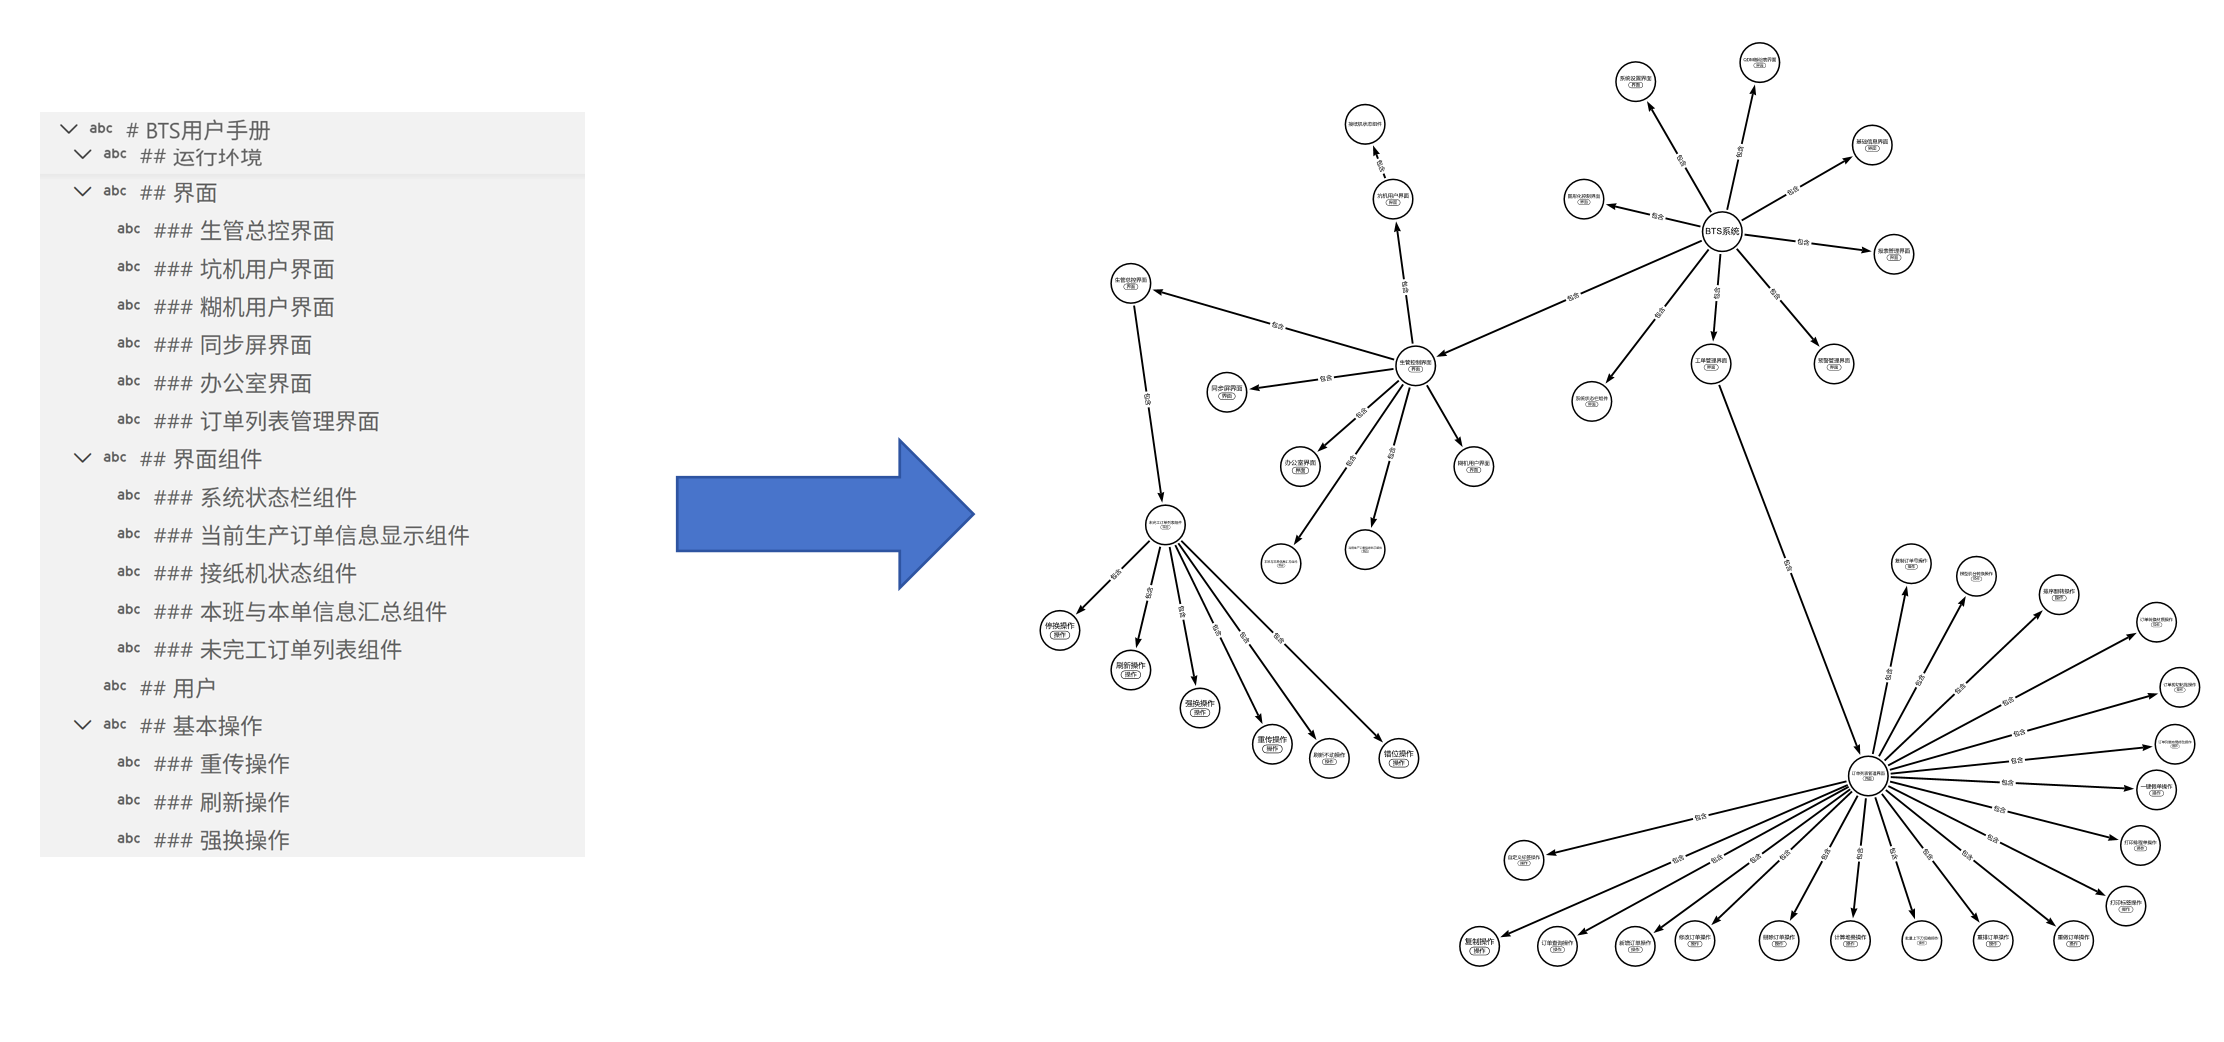

## Vector embedding

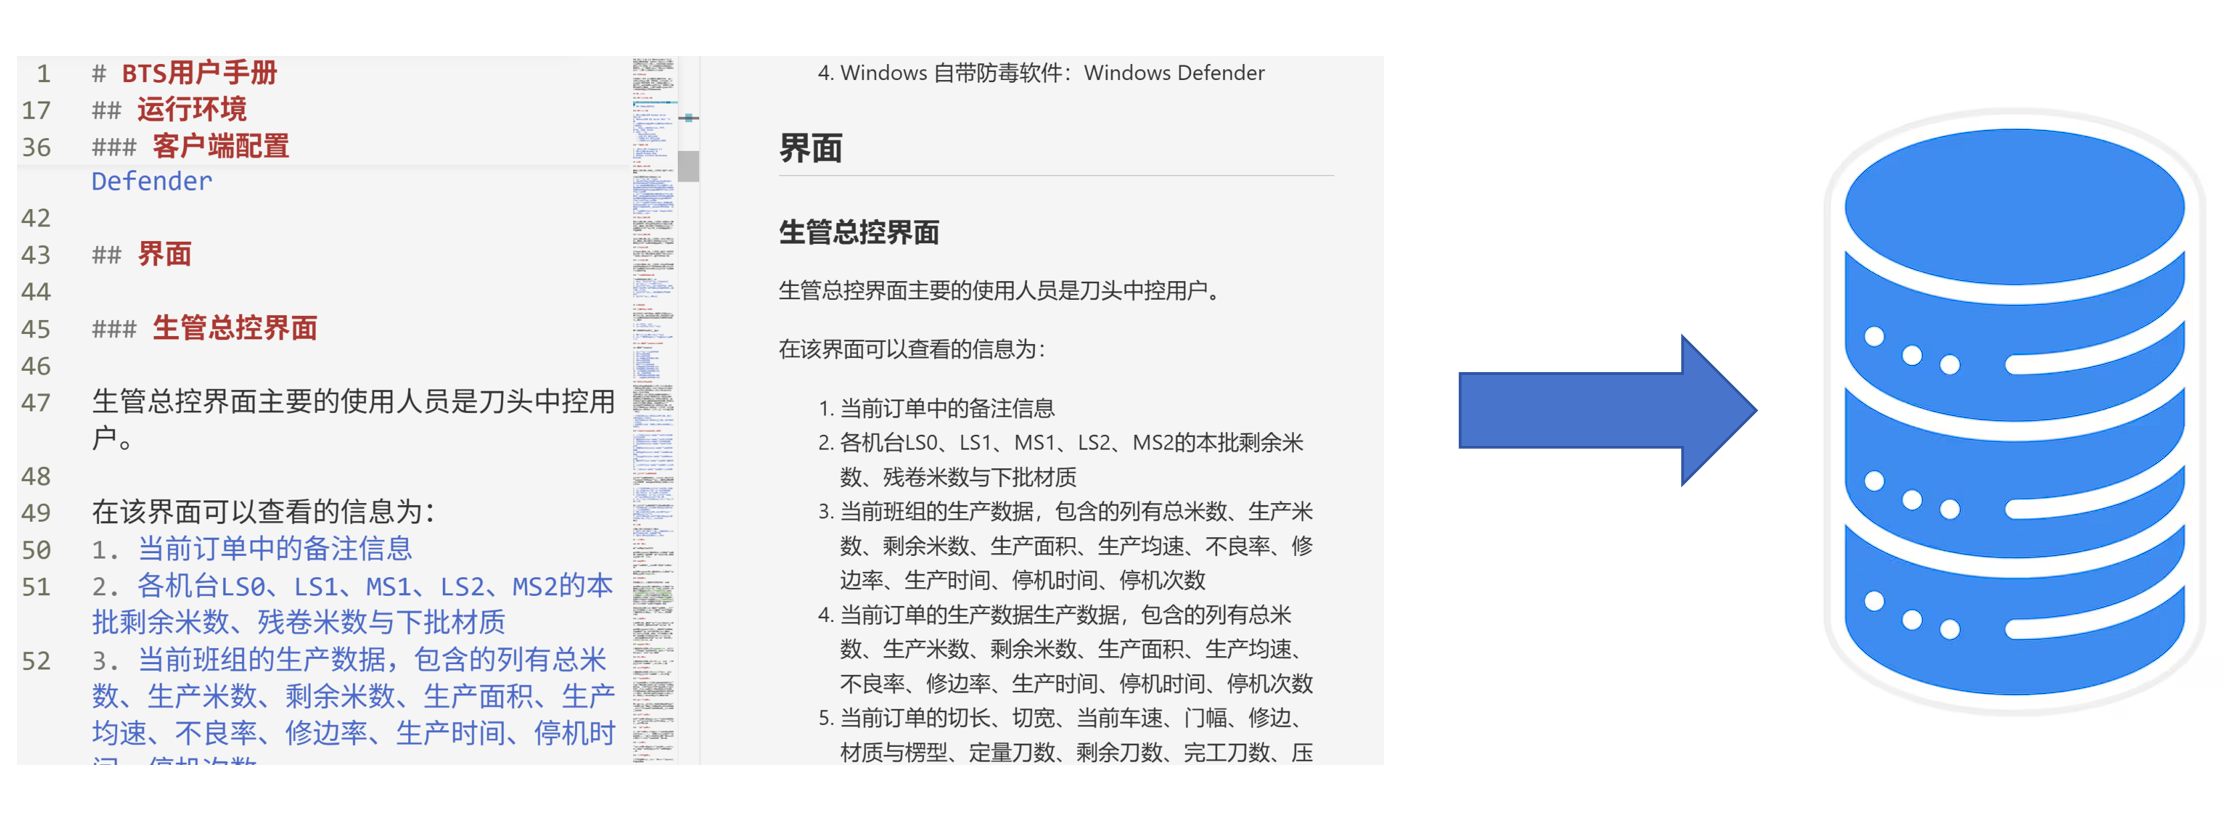

In [ ]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="Qwen/Qwen3-Embedding-0.6B")

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings) # in production, need to change to chromadb
markdown_user_manual_path = "/kaggle/input/datasets/patrickhuang00017/bts-user-manual/user_manual.md"

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    add_start_index=True,
)
# read markdown file
with open(markdown_user_manual_path, "r", encoding="utf-8") as f:
    content = f.read()
base_doc = [Document(page_content=content)]
print(f"Total characters: {len(base_doc[0].page_content)}")
user_manual_docs = text_splitter.split_documents(base_doc)
print(f"Split blog post into {len(user_manual_docs)} sub-documents.")
# now, do embedding
_ = vector_store.add_documents(documents=user_manual_docs)

In [ ]:
# handle markdown
def extract_h3_headings_v2(markdown_file: str) -> Dict[str, str]:
    """
    逐行解析Markdown文件，提取###标题及其内容
    遇到任何标题（#、##、###等）都视为当前内容的结束
    """
    with open(markdown_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    result = {}
    current_title = None
    current_content = []

    for line in lines:
        line_stripped = line.lstrip()  # 去除开头的空格，但保留缩进

        # 检查是否是任何级别的标题（以#开头）
        if line_stripped.startswith("#"):
            # 如果是###标题，开始新的记录
            if line_stripped.startswith("### "):
                # 如果之前有正在处理的标题，保存它
                if current_title:
                    result[current_title] = "".join(current_content).strip()

                # 开始新的标题
                current_title = line_stripped[4:].strip()  # 去掉'### '前缀
                current_content = []
            else:
                # 如果是其他级别的标题（# 或 ##），且当前正在收集内容
                if current_title:
                    # 保存当前###标题的内容
                    result[current_title] = "".join(current_content).strip()
                    # 重置，不再收集内容（因为新标题不是###）
                    current_title = None
                    current_content = []
                # 如果当前没有在收集内容，什么也不做
        elif current_title:
            # 如果当前在某个###标题下，添加内容
            current_content.append(line)

    # 保存最后一个标题
    if current_title:
        result[current_title] = "".join(current_content).strip()

    return result

In [ ]:
key2text = extract_h3_headings_v2(markdown_user_manual_path)

## Create LLM Model

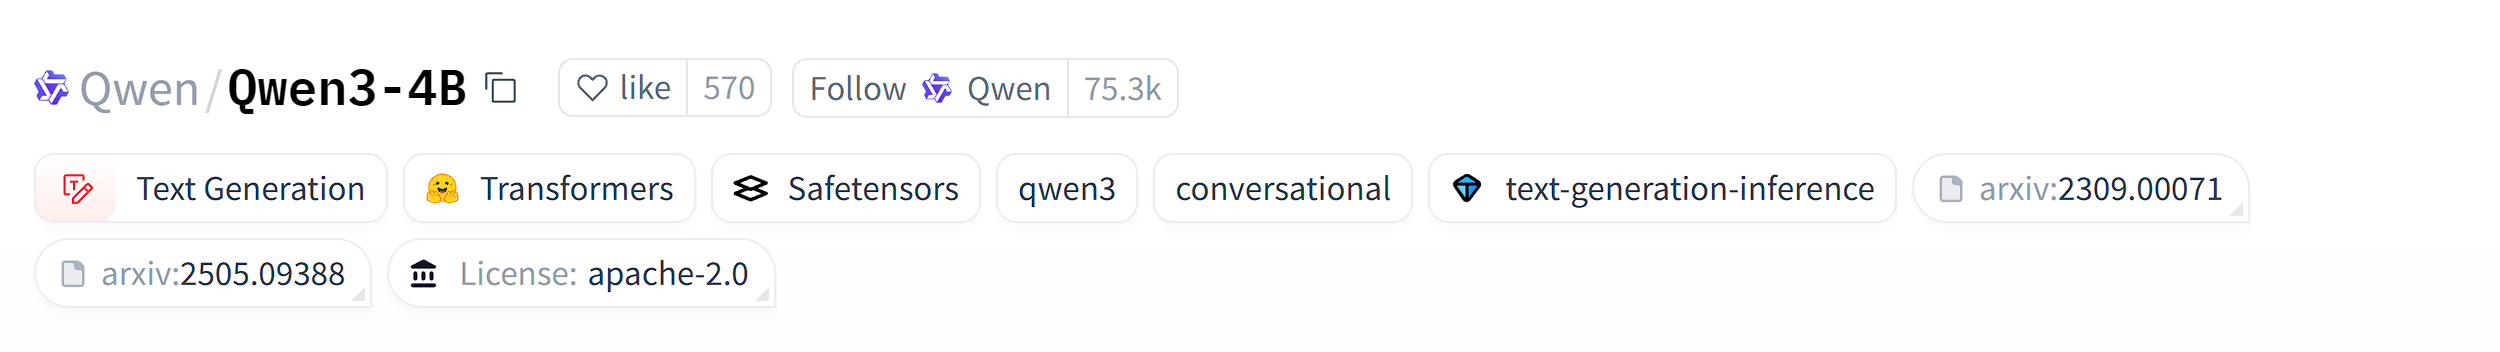

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline

# model = OllamaLLM(model="qwen3:4b")

llm = HuggingFacePipeline.from_model_id(
    model_id="Qwen/Qwen3-0.6B",
    task="text-generation",
    pipeline_kwargs=dict(
        max_new_tokens=2048,
        max_length=4096,
        do_sample=False,
        repetition_penalty=1.03,
    ),
)

chat_model = ChatHuggingFace(llm=llm, Reasoning=False)

## Create agents

### Workflow

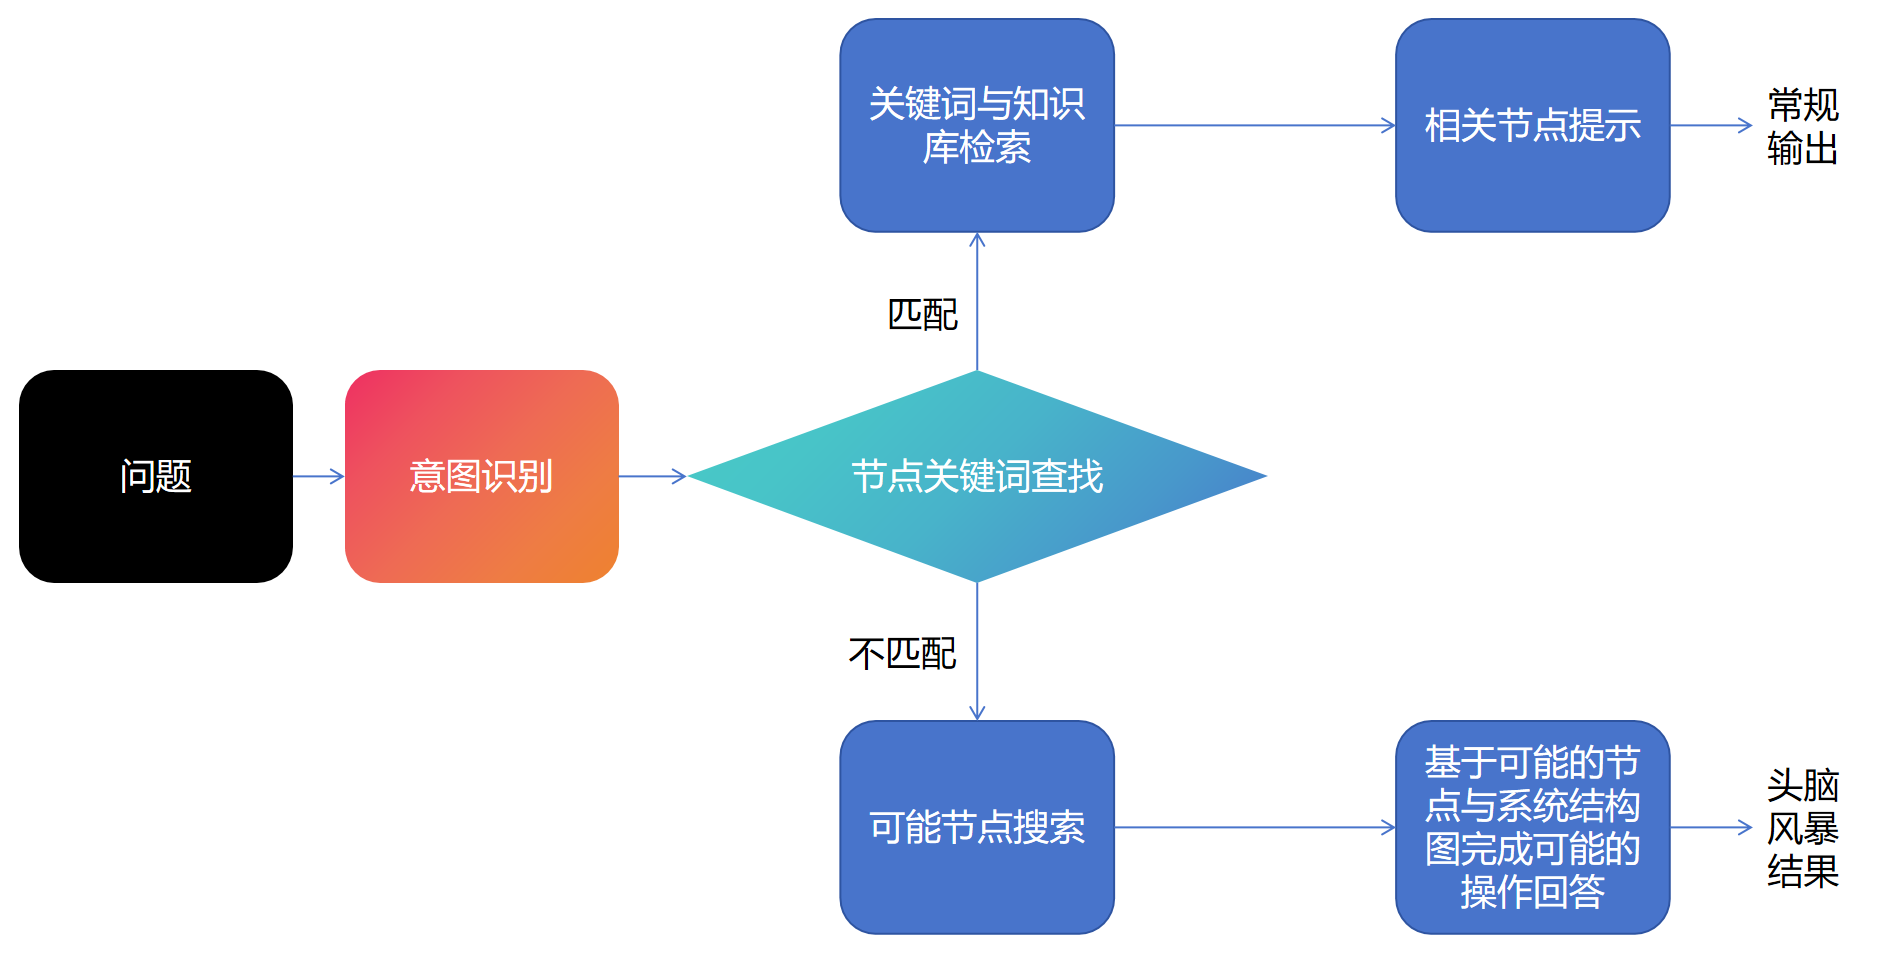

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

### Intention Agent

In [ ]:
"""
todo: define the output structure

from enum import Enum
from pydantic import BaseModel
from typing import List

class TestAttribute(Enum):
    attribute1 = "attribute1"
    attribute2 = "attribute2"

class TestExtract(BaseModel):
    test_attributes: List[TestAttribute]
""" 


all_ui_nodes = query_all_nodes_by_label(loaded_graph, "界面")
all_operate_nodes = query_all_nodes_by_label(loaded_graph, "操作")
intent_agent_system_prompt = f"""你是一个用户意图分析助手。
用户的提问都是与系统的使用有关的，按照用户的问题对其意图进行分析，并接着判断询问的是哪个确切的模块。
用户意图可以分为三类，分别是界面、操作、流程。
关于界面的意图中，确切的模块有: {all_ui_nodes}；
关于操作的意图中，确切的模块有：{all_operate_nodes}；
关于流程的意图中，确切的模块有：停换操作流程

若没有可以匹配的模块，则用于意图与确切的模块都填写为未知。
当用户的问题比较复杂时，则意图与确切的模块都填写未知。

必须以严格的JSON格式返回所有响应。

## 响应格式要求
- 所有输出必须是有效的JSON对象
- 不要包含任何额外的文本、解释或markdown标记
- 不要使用代码块包裹JSON
- 确保JSON格式正确，可以被直接解析

## JSON结构
{{
    "question": "直接摘抄用户问题",
    "intent": "界面、操作、流程或未知", // 不能判断为其他类别
    "module": "确切的模块或未知"  // 选择上述提到的一个确切的模块，不要输入其他不相关模块
}}

## 示例1
用户：强换操作如何使用？
助手：{{"question": "强换操作如何使用？", "intent": "操作", "module": "强换操作"}}

## 示例2
用户：停换操作的完成流程是怎样的？
助手：{{"question": "停换操作的完成流程是怎样的？", "intent": "流程", "module": "停换操作流程"}}

请始终遵循以上格式。"""
intent_agent = create_agent(
    chat_model, tools=[], system_prompt=intent_agent_system_prompt
)

### RAG Agent

In [ ]:
@dynamic_prompt
def prompt_with_context(request: ModelRequest) -> str:
    """
    用于不用思考流程的RAG部分
    """
    # inject context into state messages
    docs_content = ""
    last_query = request.state["messages"][-1].text
    if docs != "":
        docs_content += f"\n{docs}"

    retrieved_docs = vector_store.similarity_search(last_query, k=2)
    # print(f"使用向量数据库查询到的文档有：{len(retrieved_docs)}")
    docs_content += "\n".join(doc.page_content for doc in retrieved_docs)
    system_prompt = f"""
你是一个用户手册文档助手，该文档是关于BTS开发的IPS智能瓦楞纸板生产线的系统使用手册。
按照用户的问题，严格按照查询到的有关文档信息进行回答。使用的语句尽可能专业。
不要有任何在文档以外的内容，不要有任何在文档以外的内容，不要有任何在文档以外的内容。
查询到的相关文档如下：{docs_content}
"""
    # print(f"part2 system prompt: {system_prompt}")
    return system_prompt

doc_agent = create_agent(chat_model, tools=[], middleware=[prompt_with_context])

### Graph Agent

In [ ]:
@dynamic_prompt
def prompt_with_neo4j_graph(request: ModelRequest) -> str:
    """
    用于不用思考流程的Graph部分
    """
    # as we all know this text is json format
    last_query = request.state["messages"][-1].text
    try:
        parsed_intent_output = json.loads(last_query)
        intent = parsed_intent_output["intent"]
        module = parsed_intent_output["module"]
    except json.JSONDecodeError as e:
        # print(f"JSON解析失败，原文：{last_query}")
        intent = ""
        module = ""

    related_results = query_node_relationships(loaded_graph, module)
    # {
    #     "node_name": node_name,
    #     "contains_arr": sorted(contains_arr),  # 排序使输出更整齐
    #     "related_arr": sorted(related_arr),
    # }
    # create system prompt
    system_prompt = f"""
你是一个用户引导助手，需要基于给出的模块关系进行总结。
模块的包含与属于关系如下: {related_results}
其中，contains_arr中为当前模块包含的子模块，related_arr中为包含当前模块的上层模块。
只对上述给出的关系进行总结，不要有任何其他内容，若无任何关系，则说明无任何关系
    """
    return system_prompt

graph_agent = create_agent(chat_model, tools=[], middleware=[prompt_with_neo4j_graph])

### Graph fetch useful node agent

In [ ]:
@dynamic_prompt
def prompt_fetch_useful_graph(request: ModelRequest) -> str:
    """
    用于头脑风暴流程的抓取有用知识图节点
    """
    all_nodes = query_all_nodes(loaded_graph)
    # {
    #     "node_name": node_name,
    #     "contains_arr": sorted(contains_arr),  # 排序使输出更整齐
    #     "related_arr": sorted(related_arr),
    # }
    # create system prompt
    system_prompt = f"""
你是一个用户问题分析助手。
用户的提问都是与系统的使用有关的，对用户的问题进行分析，并接着判断问题需要使用到系统的哪个部分。
现已经使用图谱的形式将系统之间的关系进行了建模，你只需要对节点进行抽取，判断用户的问题需要使用哪些节点，将所有节点名称填入nodes字段中。
填入的节点名称不可以重复。图中所有节点名称如下：{all_nodes}

必须以严格的JSON格式返回所有响应。

## 响应格式要求
- 所有输出必须是有效的JSON对象
- 不要包含任何额外的文本、解释或markdown标记
- 不要使用代码块包裹JSON
- 确保JSON格式正确，可以被直接解析

## JSON结构
{{
    "nodes": ["node1", "node2"], // 不能判断为其他类别
}}

请始终遵循以上格式。
    """
    return system_prompt

graph_fetch_agent = create_agent(
    chat_model, tools=[], middleware=[prompt_fetch_useful_graph]
)

### Graph path summarize agent

In [ ]:
@dynamic_prompt
def prompt_graph_rag_summary(request: ModelRequest) -> str:
    """
    用于最终的头脑风暴总结阶段
    """
    # inject context into state messages
    docs_content = ""
    last_query = request.state["messages"][-1].text
    retrieved_docs = vector_store.similarity_search(last_query, k=2)
    # print(f"使用向量数据库查询到的文档有：{len(retrieved_docs)}")
    docs_content += "\n".join(doc.page_content for doc in retrieved_docs)
    system_prompt = f"""
    你是一个系统使用培训助手，尝试理解知识图与相关文档中的内容，以专业的角度对用户问题进行回答。
    现已将操作相关的部分以图的方式呈现，尝试对用户输入的系统结构图进行理解。

    在知识库中查询到的相关文档如下：{docs_content}

    尝试整合相关文档与系统结构图，对用户的问题进行回答，尽可能不要出现文档或图范围外的不相关信息。
"""
    return system_prompt
    
graph_path_summarize_agent = create_agent(
    chat_model,
    tools=[],
    middleware=[prompt_graph_rag_summary]
)

## Workflow

In [ ]:
import json

def response(question):
    content = ""  # final answer
    no_think_content = "" # No think final answer

    #  1. intent classification and parse the json output
    intent_output = intent_agent.invoke(
        {"messages": [{"role": "user", "content": question}]}
    )
    intent_output = intent_output["messages"][-1].content
    # try to remove the think part
    intent_output = intent_output.split("</think>\n\n")[-1]
    try:
        parsed_intent_output = json.loads(intent_output)
        intent = parsed_intent_output["intent"]
        module = parsed_intent_output["module"]
    except json.JSONDecodeError as e:
        print(f"JSON解析失败，原文：{intent_output}")
        # return "没有理解"
        intent = "未知"
        module = "未知"
    no_think_content += f"\n\n 用户意图判断: {intent} - {module}"
    # print(f"part1: {intent} - {module}")
    if module != "未知":
        # Normal stage: 2. try to get the right answer in the key2text first,
        docs = ""
        if module in key2text.keys():
            # print(f"part2 find useful docs: {key2text[module]}")
            docs = key2text[module]
        doc_agent_output = doc_agent.invoke(
            {"messages": [{"role": "user", "content": question}]}
        )
        doc_agent_output = doc_agent_output["messages"][-1].content
        # print(f"part2 output: {doc_agent_output}")
        content += doc_agent_output
        no_think_content += f"\n\n {doc_agent_output.split("</think>\n\n")[-1]}"
        # Normal stage: 3. use graph agent to make the graph guide
        graph_agent_output = graph_agent.invoke(
            {"messages": [{"role": "user", "content": intent_output}]}
        )
        graph_agent_output = graph_agent_output["messages"][-1].content
        # print(f"part3: {graph_agent_output}")
        content += graph_agent_output
        no_think_content += f"\n\n {graph_agent_output.split("</think>\n\n")[-1]}"
        return content, no_think_content
    else:
        # brain storm stage 1: fetch the useful knowledge graph nodes
        graph_nodes_output = graph_fetch_agent.invoke(
            {"messages": [{"role": "user", "content": question}]}
        )
        graph_nodes_output = graph_nodes_output["messages"][-1].content
        # try to remove think part
        graph_nodes_output = graph_nodes_output.split("</think>\n\n")[-1]
        try:
            parsed_graph_nodes_output = json.loads(graph_nodes_output)
        except json.JSONDecodeError as e:
            print(f"JSON解析失败，原文：{graph_nodes_output}")
            parsed_graph_nodes_output = {"nodes": []}
            # return "没有理解"
        # print(f"brain storm stage 1: {parsed_graph_nodes_output}")
        content += f"\n抽取到的可能的操作为：{parsed_graph_nodes_output}"
        no_think_content += f"\n\n抽取到的可能的操作为：{parsed_graph_nodes_output}"
        # brain storm stage 2: make the summary for useful knowledge graph nodes
        # query the useful sub graph
        
        subgraph_content = extract_upward_subgraph(
            loaded_graph, parsed_graph_nodes_output["nodes"], relation_type="属于"
        )
        # print(f"brain storm stage 2 subgraph: {subgraph_content}")
        graph_path_summary = graph_path_summarize_agent.invoke(
            {
                "messages": [
                    {
                        "role": "user", 
                        "content": f"可能相关的知识图谱结构如下：{subgraph_content}\n 用户问题如下: {question}"
                    }
                ]
            }
        )
        graph_path_summary = graph_path_summary["messages"][-1].content
        # print(f"brain storm stage 2 output: {graph_path_summary}")
        content += f"\n{graph_path_summary}"
        no_think_content += f"\n\n {graph_path_summary.split("</think>\n\n")[-1]}"
        return content, no_think_content

## Test

In [ ]:
question1 = "如何进行订单修改"
ans1, nothink1 = response(question1)
print(f"问题：{question1}")
print(f"回答：{nothink1}")

In [ ]:
# question2 = "解释一下强换操作"
# ans2, nothink2 = response(question2)
# print(f"问题：{question2}")
# print(f"回答：{nothink2}")

In [ ]:
# question2 = "解释一下强换操作"
# ans2, nothink2 = response(question2)
# print(f"问题：{question2}")
# print(f"回答：{nothink2}")

In [ ]:
# 打开并读取JSON文件
# with open("/kaggle/input/datasets/patrickhuang00017/bts-question-answer-dataset/qa.json", 'r', encoding='utf-8') as file:
#     data = json.load(file)
# answers = []
# for content in data:
#     question = content["question"]
#     content, nothink = response(question)
#     answers.append({
#         "question": question,
#         "content": content,
#         "no_think": nothink
#     })
# # 保存answers到JSON文件
# output_file = "/kaggle/working/answers_output.json"
# with open(output_file, 'w', encoding='utf-8') as f:
#     json.dump(answers, f, ensure_ascii=False, indent=2)

# print(f"成功保存 {len(answers)} 条答案到 {output_file}")